## Bispectrum Lattice XRD Tutorial

Author: Elyssa Hofgard

Date: 11/23/24

This tutorial demonstrates how to calculate the bispectrum with radial basis functions from a lattice in reciprocal space, how one would invert the bispectrum to obtain the lattice in real space, and how to calculate the XRD pattern/d-spacing for a given lattice. I have most of these functions in ``utilities.py``. I put them self-contained in this notebook so the user can see how they work. 

### 1. Obtaining lattice/calculating XRD pattern

We first read the lattice from a cif file and calculate the XRD pattern using pymatgen tools.

In [52]:
### import statements
#from mp_api.client import MPRester
from pymatgen.core import Structure
from pymatgen.core import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
import numpy as np
from pymatgen.analysis.structure_analyzer import SpacegroupAnalyzer
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import ase
from matscipy.neighbours import neighbour_list
import plotly.graph_objects as go
import torch
import e3nn
from e3nn import o3, io

In [53]:
# read cif file using pymatgen
si = Structure.from_file('si.cif')

In [54]:
# look at lattice
si

Structure Summary
Lattice
    abc : 5.44370237 5.44370237 5.44370237
 angles : 90.0 90.0 90.0
 volume : 161.31810712835818
      A : 5.44370237 0.0 3.33330634146568e-16
      B : -3.33330634146568e-16 5.44370237 3.33330634146568e-16
      C : 0.0 0.0 5.44370237
    pbc : True True True
PeriodicSite: Si0 (Si) (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]
PeriodicSite: Si0 (Si) (1.361, 1.361, 1.361) [0.25, 0.25, 0.25]
PeriodicSite: Si0 (Si) (-1.667e-16, 2.722, 2.722) [0.0, 0.5, 0.5]
PeriodicSite: Si0 (Si) (4.083, 1.361, 4.083) [0.75, 0.25, 0.75]
PeriodicSite: Si0 (Si) (1.361, 4.083, 4.083) [0.25, 0.75, 0.75]
PeriodicSite: Si0 (Si) (4.083, 4.083, 1.361) [0.75, 0.75, 0.25]
PeriodicSite: Si0 (Si) (2.722, 0.0, 2.722) [0.5, 0.0, 0.5]
PeriodicSite: Si0 (Si) (2.722, 2.722, 3.333e-16) [0.5, 0.5, 0.0]

In [55]:
# get the primitive structure and lattice
si_prim = si.get_primitive_structure()
si_prim

Structure Summary
Lattice
    abc : 3.8492788605882797 3.8492788605882797 3.8492788605882797
 angles : 59.99999999999999 59.99999999999999 59.99999999999999
 volume : 40.32952678208955
      A : -2.721851185 -2.721851185 0.0
      B : -2.721851185 0.0 -2.721851185
      C : 1.66665317073284e-16 -2.721851185 -2.721851185
    pbc : True True True
PeriodicSite: Si0 (Si) (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]
PeriodicSite: Si0 (Si) (-4.083, -4.083, -4.083) [0.75, 0.75, 0.75]

Note the XRD pattern depends on the wavelength measured at, 0.775 Angstrom was used by collaborators at Berkeley National Lab. Additionally, note that XRDCalculator in pymatgen will produce much cleaner peaks than are seen in experimental data (as from solid state physics, we know how to calculate XRD patterns theoretically). This is why people using the Materials Project/synthetic data must then use peak broadening/data augmentation to mimic experimental data. 

In [56]:
# calculate XRD pattern using pymatgen tools with specific wavelength
# this is one of the wavelengths
wavelength = 0.775
xrdc = XRDCalculator(wavelength=wavelength, symprec=1e-2, debye_waller_factors=None)
xrdc_pattern = xrdc.get_pattern(si_prim).as_dict()

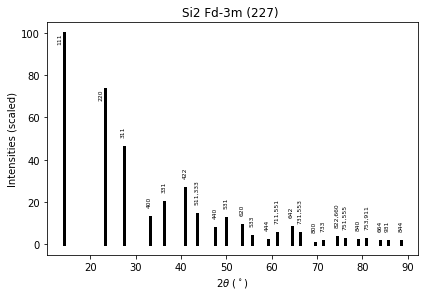

In [57]:
# we can plot using pymatgen
xrdc_plot = xrdc.plot_structures([si_prim])

In [58]:
# xrdc pattern contains two-theta values (x), intensities (y), 'hkls', and 'd_hkls'
xrdc_pattern.keys()

dict_keys(['@module', '@class', '@version', 'x', 'y', 'hkls', 'd_hkls'])

This is leftover from a previous iteration of the project, so it may not be applicable, as I think it makes more sense to use d-spacing. However, if you wanted to generate a powder patten that looks nicer with Gaussian peaks, here is an example of how to do so.

In [59]:
def gen_powder_pattern(tt, intensities, min_2theta=0, max_2theta=90, length=5000, sigma=0.25):
    """
    generates a powder pattern of uniform length and finite peak width with Gaussian shape
    Following pymatgen conventions https://pymatgen.org/pymatgen.analysis.diffraction.xrd.html
    tt: two theta peak positions
    intensities: peak intensities
    min/max_2theta: this range is too large for experimental applications but is here for illustration
    length: length of array
    sigma: peak blurring
    """
    lnx = np.linspace(min_2theta,max_2theta, length)
    pdf = np.zeros(shape=lnx.shape)
    for pos, height in zip(tt, intensities):
        pdf +=height*(stats.norm.pdf(lnx, pos, sigma))
    # normalizing intensity
    return lnx, pdf/np.max(pdf)

In [60]:
# example of how you could blur each peak us
tt, fitted_pattern = gen_powder_pattern(xrdc_pattern['x'],xrdc_pattern['y'])

Text(0.5, 0, '2$\\theta$')

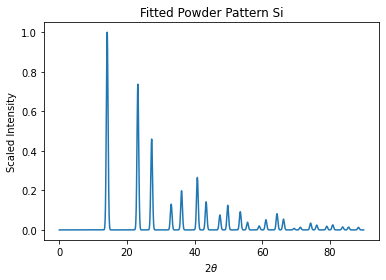

In [61]:
plt.plot(tt,fitted_pattern)
plt.title('Fitted Powder Pattern Si')
plt.ylabel('Scaled Intensity')
plt.xlabel(r"2$\theta$")

Note that we can convert from $2\theta$ to $d$-spacing with the formula
$$
d = \frac{\lambda}{2\sin(2\theta/2)}
$$
Below we confirm this is the same as the ``d_hkls`` from pymatgen.
The $q^2$ spacing used in David's method is then
$$
q^2 = 1/d^2 = \left(\frac{2\sin(2\theta/2)}{\lambda}\right)^2
$$
We also would not use such a large $2\theta$ range as above, based on David's analysis it might be reasonable to set $2\theta \in [1,25]$. This may be another limitation with machine learning approaches as most of them might be using more peaks than are actually experimentally available (would be good to check on this).

### 2. Calculating the lattice descriptor

#### 2.1 Getting reciprocal lattice

Now that we have the crystal lattice, we can calculate the lattice descriptor using the bispectrum. We first convert the lattice to reciprocal space. Let the lattice matrix be $M$. 

The only difference between ``pymatgen.lattice.reciprocal_lattice`` and ``pymatgen.lattice.reciprocal_lattice_crystallographic`` is the crystallographic setting does not have a factor of $1/(2\pi)$. I have been working with the crystallographic setting for simplicity. The lattice matrix in reciprocal space here is just $M^{-1}$.


In [62]:
recip_lattice = si_prim.lattice.reciprocal_lattice_crystallographic

In [63]:
recip_lattice

Lattice
    abc : 0.3181751480599182 0.3181751480599182 0.3181751480599182
 angles : 109.47122063449069 109.47122063449069 109.47122063449069
 volume : 0.02479572858375573
      A : -0.1836985073818428 -0.1836985073818428 0.1836985073818428
      B : -0.1836985073818428 0.1836985073818428 -0.1836985073818428
      C : 0.1836985073818428 -0.1836985073818428 -0.1836985073818428
    pbc : True True True

In [64]:
np.linalg.inv(si_prim.lattice.matrix)

array([[-0.18369851, -0.18369851,  0.18369851],
       [-0.18369851,  0.18369851, -0.18369851],
       [ 0.18369851, -0.18369851, -0.18369851]])

#### 2.2 Tiling Lattice in Reciprocal Space

We use the ``ase`` library (similar to ``pymatgen``) to tile the lattice in reciprocal space and ``matscipy`` to get a list of the atomic positions. Note we need to define a k_max cutoff (I had been experiencing with different cutoffs). Ideally, the cutoff would need to be small enough to see each lattice point once. Technically, this is fixed by the XRD wavelength and is proportional to $1/\lambda$. I had also been experimenting with doing a Miller index cutoff once the neighbors are calculated (as if there are too many points, it may be difficult to resolve the signal).

In [65]:
k_max = 2/3
recip = ase.Atoms(symbols = ['C'],positions = np.array([[0.0,0.0,0.0]]),cell=recip_lattice.matrix,pbc=True)
# neighbor list gives atomic distanes and miller indices
neighs_dist,neighs_miller = neighbour_list('dS',recip,cutoff=k_max)
# get the atomic positions
neighs_dist = np.asarray(neighs_dist)
neighs_miller = np.asarray(neighs_miller)
neighs = torch.tensor(neighs_miller.reshape(-1,3)@recip_lattice.matrix)


In [66]:
def plot_pos(neighs, title):

    # Create the 3D scatter plot
    fig = go.Figure(data=[go.Scatter3d(x=neighs[:,0], y=neighs[:,1], z=neighs[:,2], mode='markers', marker=dict(size=4))])

    # Customize the layout
    fig.update_layout(
        scene=dict(
            xaxis=dict(title='X',showgrid=False),   # Set the range for the x-axis
            yaxis=dict(title='Y',showgrid=False),   # Set the range for the y-axis
            zaxis=dict(title='Z',showgrid=False),   # Set the range for the z-axis
            #aspectmode='cube'
        ),
        title='3D Positions ' + title,
    )

    # Show the plot
    fig.show()


In [67]:
# plot the neighbors
plot_pos(neighs,"Si Neighbors")

#### 2.3 Calculating the Bispectrum

We now have enough information to calculate the bispectrum in reciprocal space. We first take the spherical harmonic projection of the distance vectors, project their norm onto a set of radial basis functions $b$, and sum over each vector. This leads to coefficients
$$
x_{blm} = \sum_{j}Y_{lm}(\vec{r}_j)R_b(|\vec{r}_j|)
$$
We take the tensor product of the coefficients with itself twice and then extract the scalar and pseudoscalar terms. Note $S_b$ is the spectrum for a specific radial basis function.
$$
S_b = (x_{blm} \otimes x_{blm} \otimes x_{blm})_{(0e,0o)}
$$
The total bispectrum is then of shape (# of basis functions, # of scalar + pseudoscalar terms). Note that we can speed up the calculation by symmetrizing the tensor through a change of basis matrix. This is implemented in ``e3nn-jax``reduced tensor product.

In [68]:
radial_function = "bessel"
n_basis = 10
lmax = 6
sph = io.SphericalTensor(lmax, 1, -1)

In [69]:
import e3nn_jax as e3nn_jax
rtp_bi = e3nn_jax.reduced_symmetric_tensor_product_basis(sph, 3, keep_ir=['0o', '0e'])
cob_bi = torch.tensor(rtp_bi.array,dtype=torch.float64)

In [70]:
def get_bispectrum(vec,k_max,lmax,radial_function,n_basis,cob_bi):
    bases = ["bessel","gaussian", "cosine", "smooth_finite", "fourier","none"]
    assert radial_function in bases, "Invalid basis function"
    #res = torch.zeros(vec.shape[0],n_basis,(sph.lmax+1)**2)
    # get spherical harmonics
    sph_harm = o3.spherical_harmonics(range(0,lmax+1),vec,normalize="False")
    radii = torch.linalg.norm(vec,axis=-1)
    basis = e3nn.math.soft_one_hot_linspace(radii,0,k_max,number=n_basis,basis=radial_function,cutoff=False)
    # Add a new dimension to the tensors
    sph_harm = sph_harm.unsqueeze(1)  # shape: (136, 10, 1)
    basis = basis.unsqueeze(2)  # shape: (136, 1, 49)
    combined_tensor = torch.matmul(basis,sph_harm)
    radial_proj = torch.sum(combined_tensor,axis=0)
    bispec = torch.einsum("...i,...j,...k,ijkz->...z",radial_proj,radial_proj,radial_proj,cob_bi)
    return bispec

In [71]:
bispec_Si = get_bispectrum(neighs,k_max,lmax,radial_function,n_basis,cob_bi)

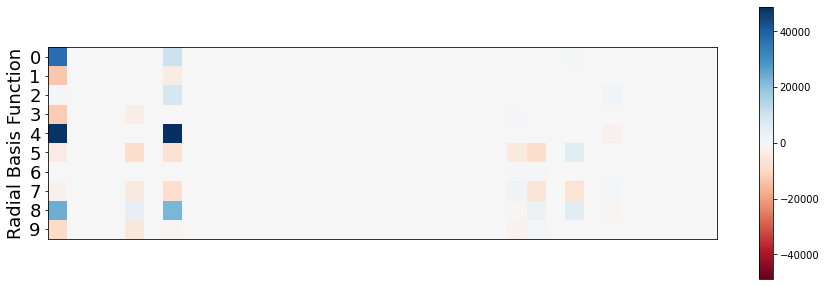

In [ ]:
# plot it
# note that many values are zero due to the high symmetry of the lattice
vmax = bispec_Si.abs().max()
fig, ax = plt.subplots(figsize=(15,5))
plt.imshow(bispec_Si,cmap="RdBu",vmax=vmax,vmin=-vmax)
plt.xticks([])
plt.yticks(np.linspace(0, bispec_Si.shape[0] - 1, num=10),fontsize=18)
plt.ylabel('Radial Basis Function',fontsize=18)
plt.colorbar()

### Todo: add example of inverting bispectrum to get back to lattice

In [73]:
### TODO: for paper, have proof showing spectra are the same regardless of unit cell convention ###
### use 1/d^2 spacing for scale invariance ###